# FPL master dataset - exploratory data analysis\n\nPython re-implementation of the EDA originally done in R for the Master's thesis phase of this project (see `RESEARCH_LOG.md` for the project's history; the original `legacy/R Forecast/EDA.R` script and its output plots were deleted once this pipeline replaced the old R/LSTM system - this notebook is a from-scratch Python rebuild of the same analyses, not a port of that file's code).\n\nCovers, per EPL position (GK/DEF/MID/FWD) and per season:\n\n- descriptive statistics of `total_points` (all players, players who featured at all, and starters)\n- distribution shape: boxplots, KDE density plots, QQ plots against a normal reference\n- season-over-season comparison of the scoring distribution\n- a ridgeline view of the points distribution across positions\n- formal stationarity (ADF) and normality (Shapiro-Wilk) tests\n\n**Why this matters for the modeling choices elsewhere in the repo:** `total_points` is heavily right-skewed and zero-inflated (most player-gameweeks score 0-2 points, with an occasional double-digit outlier), which is exactly why `fpl/model/metrics.py` uses MASE instead of raw MAE, and why several classic forecasting baselines tested in `fpl/model/baselines.py` (Croston's method in particular) were motivated by - and ultimately still lost to - this distribution shape. This notebook is the empirical evidence behind those decisions, not just a formality."

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

sys.path.insert(0, str(Path.cwd().parent))
from fpl import config

sns.set_theme(style="whitegrid")
POSITIONS = ["GK", "DEF", "MID", "FWD"]
POSITION_ORDER = {p: i for i, p in enumerate(POSITIONS)}


In [2]:
df = pd.read_csv(config.MASTER_DATASET_PATH, low_memory=False)
df["position"] = pd.Categorical(df["position"], categories=POSITIONS, ordered=True)

# Three player-gameweek subsets, matching the granularity the original thesis EDA used:
# - "all": every row (includes unused squad players who didn't play at all)
# - "played": minutes >= 1 (excludes unused subs/unselected players)
# - "starters": minutes >= 60 (a full, uninterrupted-ish appearance - the FPL clean-sheet threshold)
played = df[df["minutes"] >= 1]
starters = df[df["minutes"] >= 60]

print(f"Rows: all={len(df):,}  played={len(played):,}  starters={len(starters):,}")
print(f"Seasons: {sorted(df['season'].unique())}")
df.head()


Rows: all=162,981  played=66,647  starters=47,269
Seasons: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,fixture,...,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles,player_id
0,Aaron Connolly,FWD,Brighton,0.5,0,0,-3,0,0.3,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,Aaron Connolly,FWD,Brighton,4.0,0,2,27,1,11.3,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,Aaron Connolly,FWD,Brighton,2.7,0,0,2,0,12.1,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,Aaron Connolly,FWD,Brighton,2.7,0,0,7,0,0.3,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,Aaron Connolly,FWD,Brighton,3.0,1,0,13,0,10.3,40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


## Descriptive statistics

`total_points` per position, split by subset (all / played / starters) and pooled across all seasons. Reported since raw means/medians are what motivate everything downstream - e.g. a near-zero median for "all" players is the whole reason MASE (not MAE) is the metric used throughout `fpl/model/`.

In [3]:
def describe_points(frame, label):
    desc = frame.groupby("position", observed=True)["total_points"].describe()
    desc.insert(0, "subset", label)
    return desc

descriptive_stats = pd.concat([
    describe_points(df, "all"),
    describe_points(played, "played (min>=1)"),
    describe_points(starters, "starters (min>=60)"),
])
descriptive_stats.round(2)


,subset,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,,
GK,all,18077.0,0.88,2.07,-3.0,0.0,0.0,0.0,16.0
DEF,all,54919.0,1.12,2.34,-7.0,0.0,0.0,1.0,24.0
MID,all,70202.0,1.25,2.38,-3.0,0.0,0.0,2.0,26.0
FWD,all,19783.0,1.32,2.63,-2.0,0.0,0.0,1.0,24.0
GK,played (min>=1),4587.0,3.46,2.81,-3.0,2.0,2.0,6.0,16.0
DEF,played (min>=1),22414.0,2.74,3.00,-7.0,1.0,1.0,5.0,24.0
MID,played (min>=1),31187.0,2.82,2.89,-2.0,1.0,2.0,3.0,26.0
FWD,played (min>=1),8459.0,3.08,3.27,-2.0,1.0,2.0,4.0,24.0
GK,starters (min>=60),4506.0,3.51,2.81,-3.0,2.0,2.0,6.0,16.0


In [4]:
# Same breakdown, but per season too (matches the original thesis EDA's
# Position_Statistics_<subset>_<season>.txt files, one table per season there).
season_position_stats = (
    played.groupby(["season", "position"], observed=True)["total_points"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
season_position_stats


count  mean  median   std  min  max
season  position                                     
2020-21 GK          765  3.75     2.0  2.95   -2   15
        DEF        3486  3.00     2.0  3.06   -7   21
        MID        4713  2.88     2.0  2.88   -2   24
        FWD        1429  3.18     2.0  3.30   -1   21
2021-22 GK          739  3.59     2.0  2.74   -2   15
        DEF        3572  2.96     2.0  3.19   -4   21
        MID        4747  2.92     2.0  2.95   -2   24
        FWD        1403  3.04     2.0  3.16   -2   24
2022-23 GK          770  3.61     2.0  3.00   -3   15
        DEF        3776  2.63     1.0  2.86   -4   18
        MID        5322  2.74     2.0  2.79   -2   21
        FWD        1477  3.00     2.0  3.31   -2   23
2023-24 GK          776  3.19     2.0  2.64   -2   13
        DEF        3843  2.42     1.0  2.94   -4   21
        MID        5320  2.81     2.0  3.00   -2   26
        FWD        1445  3.14     2.0  3.34   -2   23
2024-25 GK          770  3.31     2.0  2.77   -2   16
        DEF        3787  2.43     1.0  2.75   -5   15
        MID        5738  2.69     2.0  2.85   -2   25
        FWD        1271  3.21     2.0  3.42   -2   18
2025-26 GK          767  3.34     2.0  2.71   -3   16
        DEF        3950  3.05     2.0  3.12   -3   24
        MID        5347  2.91     2.0  2.84   -2   20
        FWD        1434  2.95     2.0  3.12    0   19

## Boxplots: points by position, per season

First for every player-gameweek row ("all"), then restricted to starters - the "all" version is dominated by the mass of zeros from unused bench players, while the starters version shows the shape managers actually care about when picking a team.

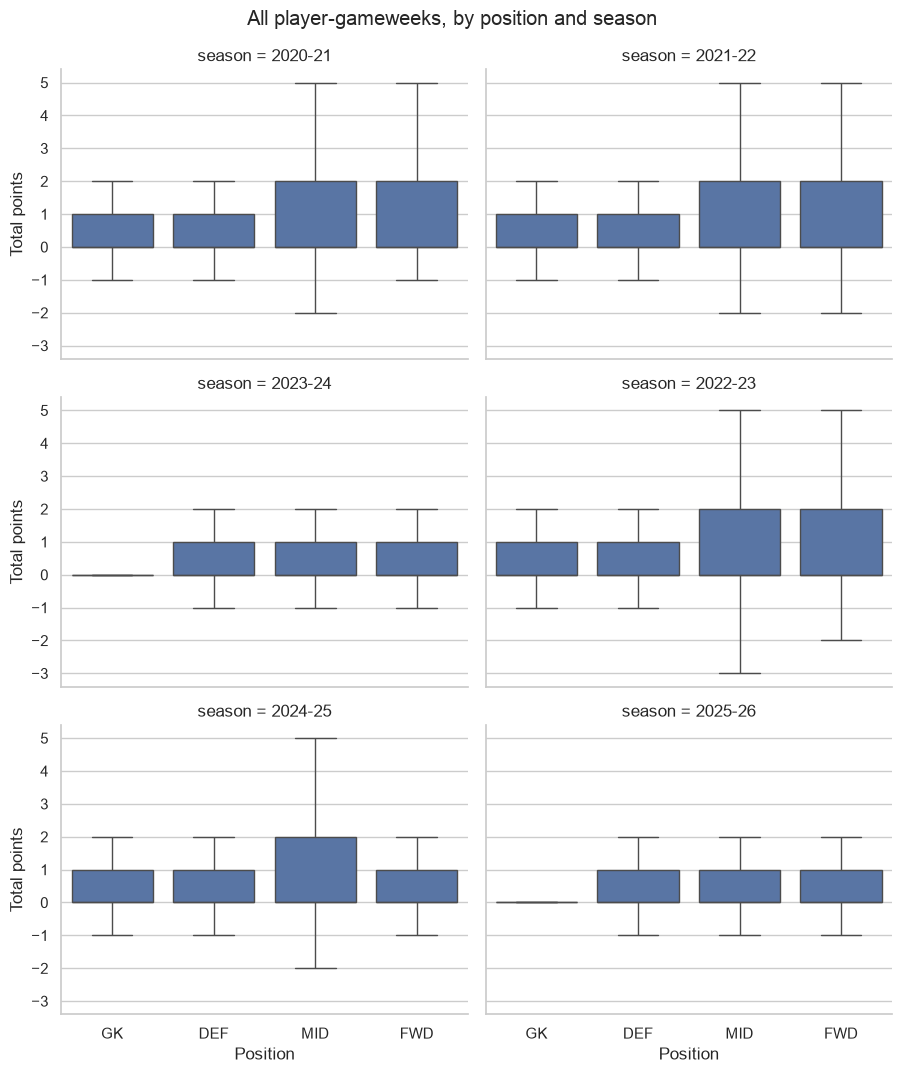

In [5]:
def boxplot_by_position_and_season(frame, title):
    g = sns.catplot(
        data=frame, x="position", y="total_points", col="season", col_wrap=2,
        kind="box", height=3.5, aspect=1.3, showfliers=False,
    )
    g.figure.suptitle(title, y=1.02)
    g.set_axis_labels("Position", "Total points")
    plt.show()

boxplot_by_position_and_season(df, "All player-gameweeks, by position and season")


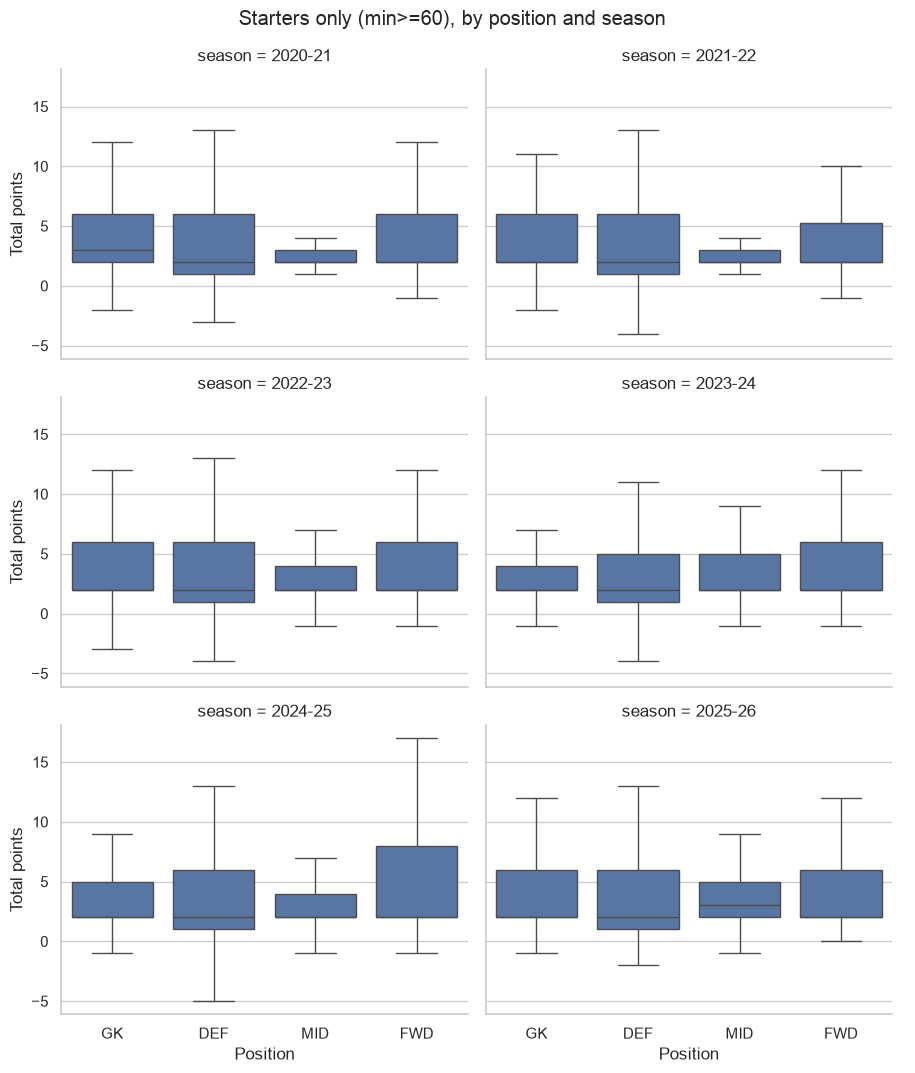

In [6]:
boxplot_by_position_and_season(starters, "Starters only (min>=60), by position and season")


## Point density distributions

Kernel density estimates make the zero-inflation and right-skew much more visible than the boxplots above - this is the shape that makes forecasting FPL points genuinely different from forecasting a roughly-normal continuous target.

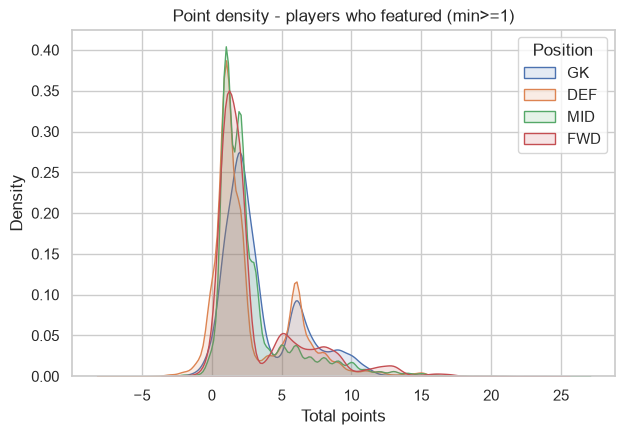

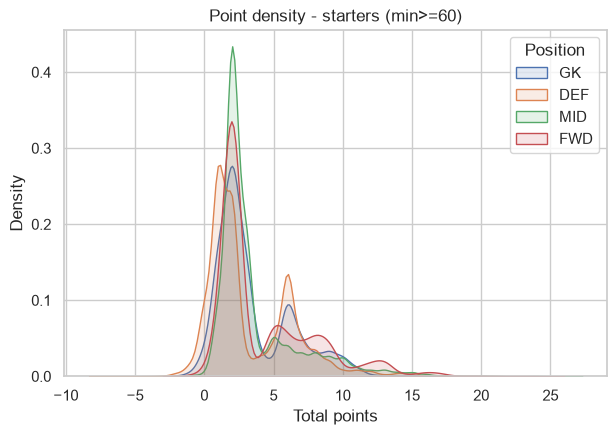

In [7]:
def density_by_position(frame, title):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for pos in POSITIONS:
        sns.kdeplot(frame.loc[frame["position"] == pos, "total_points"], label=pos, fill=True, alpha=0.15, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Total points")
    ax.legend(title="Position")
    plt.show()

density_by_position(played, "Point density - players who featured (min>=1)")
density_by_position(starters, "Point density - starters (min>=60)")


## QQ plots against a normal reference

Per position, for starters only (the "all" subset's zero-mass makes a QQ plot against a normal distribution meaningless on its face - almost every quantile below the median is just 0). Points falling on the reference line would indicate a roughly normal distribution; heavy deviation in the upper tail is the expected signature of the occasional big-haul gameweek.

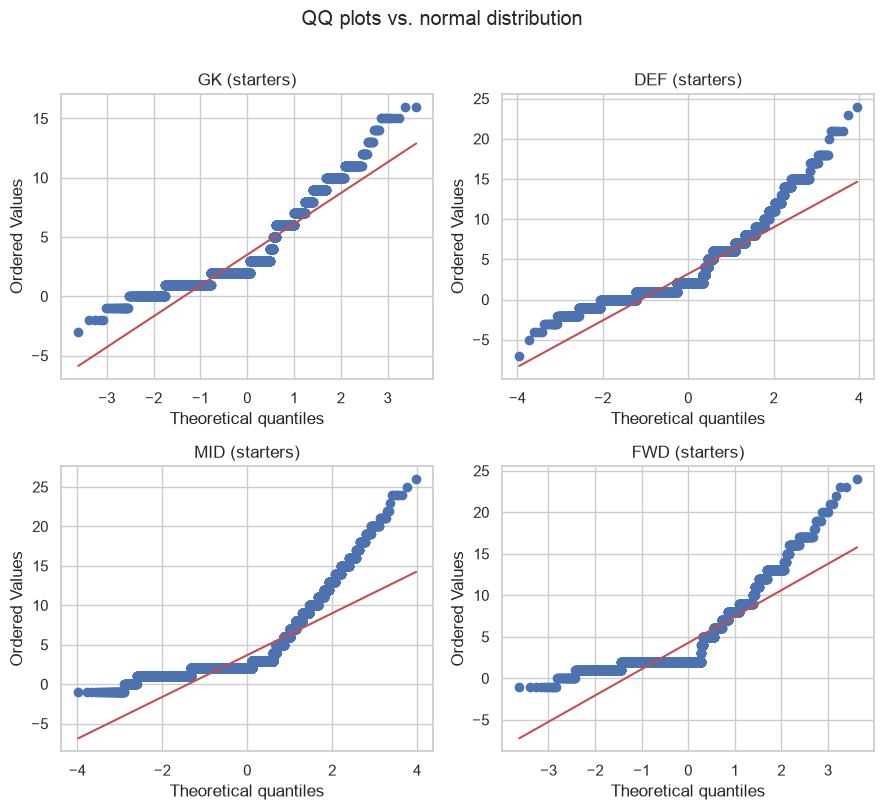

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, pos in zip(axes.flat, POSITIONS):
    stats.probplot(starters.loc[starters["position"] == pos, "total_points"], dist="norm", plot=ax)
    ax.set_title(f"{pos} (starters)")
fig.suptitle("QQ plots vs. normal distribution", y=1.01)
fig.tight_layout()
plt.show()


## Season comparison

Has the scoring distribution shifted season to season (rule changes, e.g. the 2025-26 introduction of `defensive_contribution` points - see `fpl/features.py` - could plausibly shift DEF/MID scoring)? Compared here for starters only, one line per season per position.

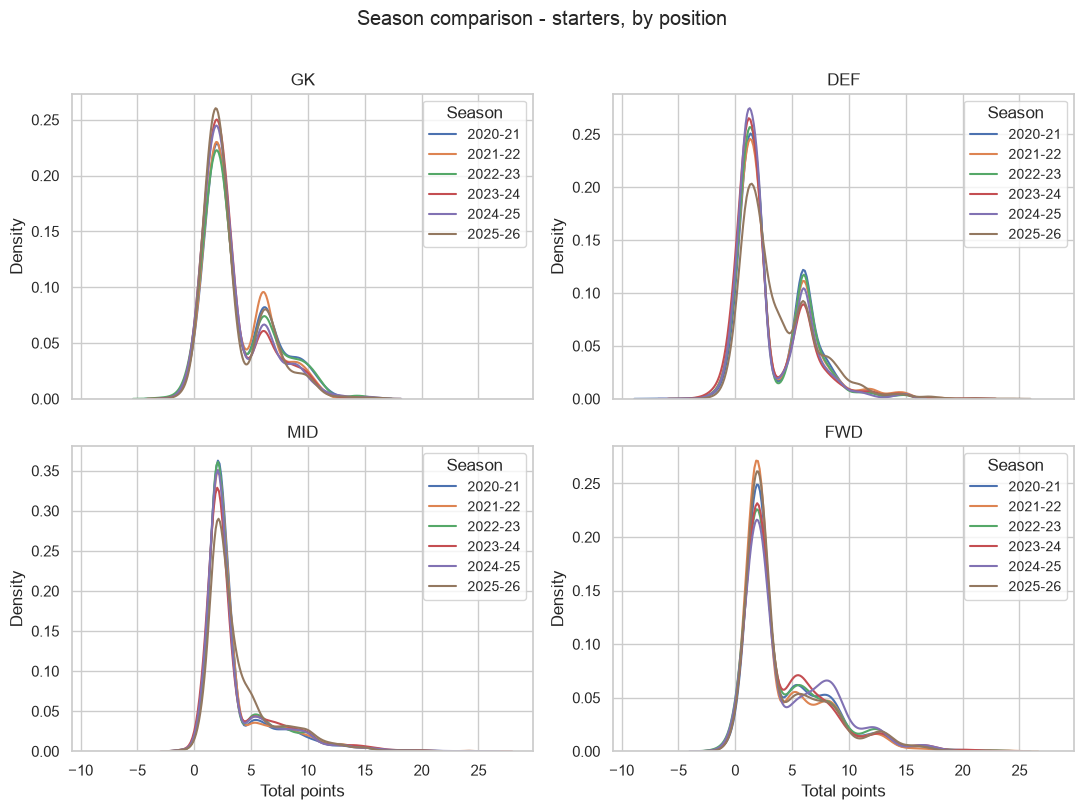

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, pos in zip(axes.flat, POSITIONS):
    pos_df = starters[starters["position"] == pos]
    for season in sorted(pos_df["season"].unique()):
        sns.kdeplot(pos_df.loc[pos_df["season"] == season, "total_points"], label=season, ax=ax)
    ax.set_title(pos)
    ax.set_xlabel("Total points")
    ax.legend(title="Season", fontsize="small")
fig.suptitle("Season comparison - starters, by position", y=1.01)
fig.tight_layout()
plt.show()


## Ridgeline plot by position

A stacked-KDE ("joyplot"-style) view of the starters' points distribution, one ridge per position, built directly with matplotlib/seaborn rather than a separate `joypy` dependency - keeps this notebook to the same dependency set as the rest of the repo (`matplotlib`/`seaborn`, no extra plotting libraries).

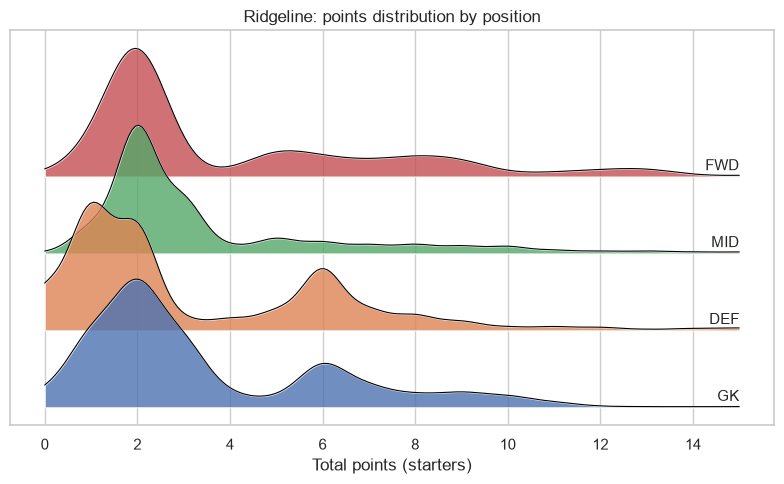

In [10]:
overlap = 0.6
fig, ax = plt.subplots(figsize=(8, 5))
x_grid = np.linspace(0, starters["total_points"].quantile(0.99), 200)

for i, pos in enumerate(POSITIONS):
    values = starters.loc[starters["position"] == pos, "total_points"]
    kde = stats.gaussian_kde(values)
    y = kde(x_grid)
    y = y / y.max()  # normalize so every ridge has the same peak height
    baseline = i * overlap
    ax.fill_between(x_grid, baseline, baseline + y, alpha=0.8, zorder=len(POSITIONS) - i)
    ax.plot(x_grid, baseline + y, color="black", linewidth=0.8, zorder=len(POSITIONS) - i)
    ax.text(x_grid[-1], baseline + 0.05, pos, fontsize=11, ha="right")

ax.set_yticks([])
ax.set_xlabel("Total points (starters)")
ax.set_title("Ridgeline: points distribution by position")
fig.tight_layout()
plt.show()


## Stationarity and normality tests\n\nFormal versions of what the plots above already suggest visually:\n\n- **Augmented Dickey-Fuller (ADF)** per position, on the average `total_points` per gameweek across the whole player pool (a single time series per position, not per individual player - individual player series are too short/gappy for a meaningful unit-root test). Null hypothesis: the series has a unit root (is non-stationary).\n- **Shapiro-Wilk** per position, on the raw starters' `total_points` distribution. Null hypothesis: the sample comes from a normal distribution. Given the skew/zero-inflation shown above, this is expected to reject normality decisively - included for completeness/rigor, not because a surprising result is expected."

In [11]:
adf_rows = []
for pos in POSITIONS:
    series = (
        played[played["position"] == pos]
        .groupby("GW_global")["total_points"]
        .mean()
        .sort_index()
    )
    stat, pvalue, *_ = adfuller(series, autolag="AIC")
    adf_rows.append({"position": pos, "adf_stat": stat, "p_value": pvalue, "stationary_at_5pct": pvalue < 0.05})

pd.DataFrame(adf_rows).round(4)


,position,adf_stat,p_value,stationary_at_5pct
0,GK,-3.0462,0.0308,True
1,DEF,-1.7368,0.4123,False
2,MID,-8.7499,0.0000,True
3,FWD,-7.0462,0.0000,True


In [12]:
# Shapiro-Wilk caps out at 5000 samples in scipy - subsample for positions with more
# starters than that, since the test's p-value isn't meaningfully more informative
# beyond that many observations anyway, just slower to compute.
shapiro_rows = []
rng = np.random.default_rng(0)
for pos in POSITIONS:
    values = starters.loc[starters["position"] == pos, "total_points"].to_numpy()
    sample = rng.choice(values, size=5000, replace=False) if len(values) > 5000 else values
    stat, pvalue = stats.shapiro(sample)
    shapiro_rows.append({"position": pos, "n": len(values), "shapiro_stat": stat, "p_value": pvalue,
                          "normal_at_5pct": pvalue > 0.05})

pd.DataFrame(shapiro_rows).round(4)


,position,n,shapiro_stat,p_value,normal_at_5pct
0,GK,4506,0.8548,0.0,False
1,DEF,18075,0.8405,0.0,False
2,MID,19866,0.7112,0.0,False
3,FWD,4822,0.7639,0.0,False


## Takeaways\n\n- `total_points` is right-skewed and zero-inflated at every position, most severely for the \"all\" subset (bench players who never played) and least severely for FWD starters (highest-variance, highest-ceiling position).\n- The Shapiro-Wilk test rejects normality decisively everywhere, confirming what the QQ plots show - upper-tail deviation from a normal reference at every position.\n- The ADF test's stationarity verdict per position (see the table above) is worth checking before trusting any classical ARIMA-style forecasting on the pooled series - ties directly into why `fpl/model/baselines.py`'s per-player ARIMA baseline (see `RESEARCH_LOG.md`) needed a `trend=\"c\"` constant term and still underperformed the existing ensemble.\n- None of this changes day to day - it's the empirical justification for decisions already made elsewhere in the repo (MASE over MAE, per-position rather than single global models, cheap tree/linear ensembles over anything assuming Gaussian errors)."